In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
colors = ['#c878a8', '#a078c8', '#f090c0', '#c0a0d0', '#9060c8']
sns.set_style("whitegrid")

In [29]:
df = pd.read_csv(r'C:\Users\Siri\synent-task6-customersegmentation-siri\Mall_Customer.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (200, 5)

First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [30]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
df.columns = ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']
df['Gender_Encoded'] = df['Gender'].map({'Male': 0, 'Female': 1})
print("\nData Types:\n", df.dtypes)
df.head()

Missing values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicates: 0

Data Types:
 CustomerID         int64
Gender            object
Age                int64
Annual_Income      int64
Spending_Score     int64
Gender_Encoded     int64
dtype: object


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Gender_Encoded
0,1,Male,19,15,39,0
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


In [31]:
print("Basic Statistics:")
df.describe()


Basic Statistics:


,CustomerID,Age,Annual_Income,Spending_Score,Gender_Encoded
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000,0.560000
std,57.879185,13.969007,26.264721,25.823522,0.497633
min,1.000000,18.000000,15.000000,1.000000,0.000000
25%,50.750000,28.750000,41.500000,34.750000,0.000000
50%,100.500000,36.000000,61.500000,50.000000,1.000000
75%,150.250000,49.000000,78.000000,73.000000,1.000000
max,200.000000,70.000000,137.000000,99.000000,1.000000


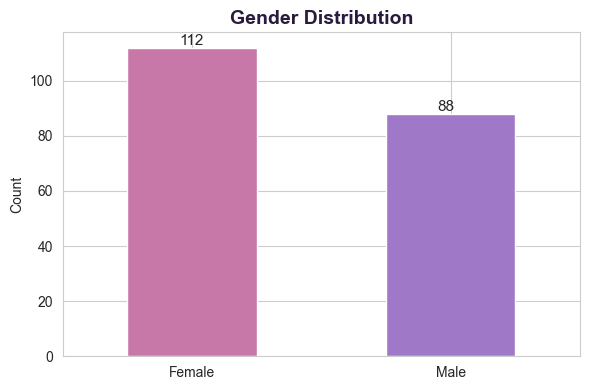

In [32]:
plt.figure(figsize=(6, 4))
ax = df['Gender'].value_counts().plot(
    kind='bar',
    color=['#c878a8', '#a078c8'],
    edgecolor='white',
    width=0.5
)
plt.title('Gender Distribution', fontsize=14, fontweight='bold', color='#2a1a3e')
plt.xlabel('')
plt.ylabel('Count')
plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x()+0.2, p.get_height()+1), fontsize=11)
plt.tight_layout()
plt.savefig('gender_dist.png', dpi=150, bbox_inches='tight')
plt.show()

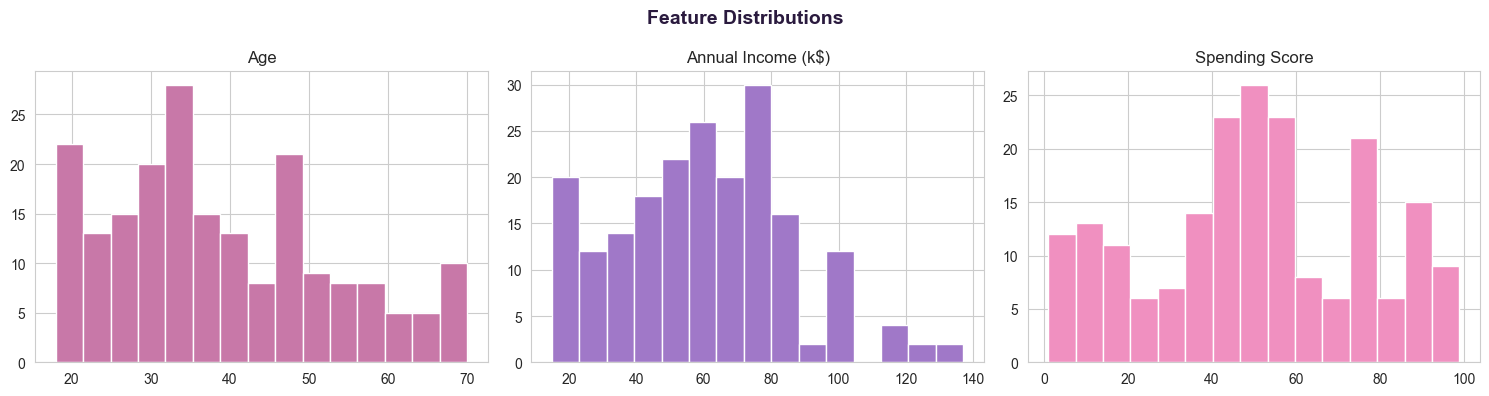

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold', color='#2a1a3e')

axes[0].hist(df['Age'], bins=15, color='#c878a8', edgecolor='white')
axes[0].set_title('Age')

axes[1].hist(df['Annual_Income'], bins=15, color='#a078c8', edgecolor='white')
axes[1].set_title('Annual Income (k$)')

axes[2].hist(df['Spending_Score'], bins=15, color='#f090c0', edgecolor='white')
axes[2].set_title('Spending Score')

plt.tight_layout()
plt.savefig('distributions.png', dpi=150, bbox_inches='tight')
plt.show()

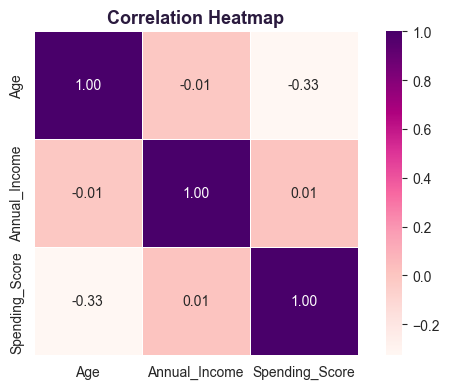

In [34]:
plt.figure(figsize=(6, 4))
corr = df[['Age', 'Annual_Income', 'Spending_Score']].corr()
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdPu',
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap', fontsize=13, fontweight='bold', color='#2a1a3e')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

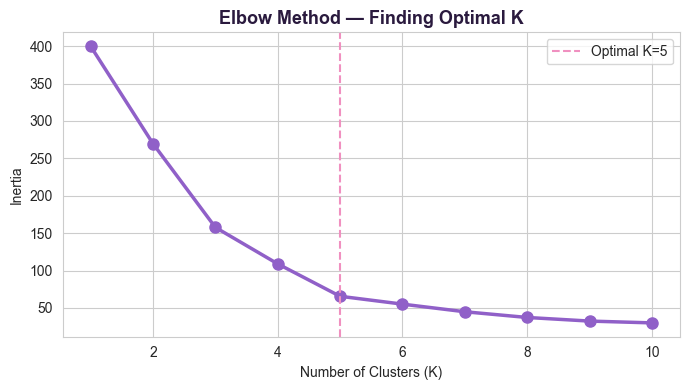

In [35]:
X = df[['Annual_Income', 'Spending_Score']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertia, 'o-', color='#9060c8', linewidth=2.5, markersize=8)
plt.axvline(x=5, color='#f090c0', linestyle='--', linewidth=1.5, label='Optimal K=5')
plt.title('Elbow Method — Finding Optimal K', fontsize=13, fontweight='bold', color='#2a1a3e')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.legend()
plt.tight_layout()
plt.savefig('elbow.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X_scaled)
print("Cluster counts:")
print(df['Cluster'].value_counts().sort_index())

Cluster counts:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


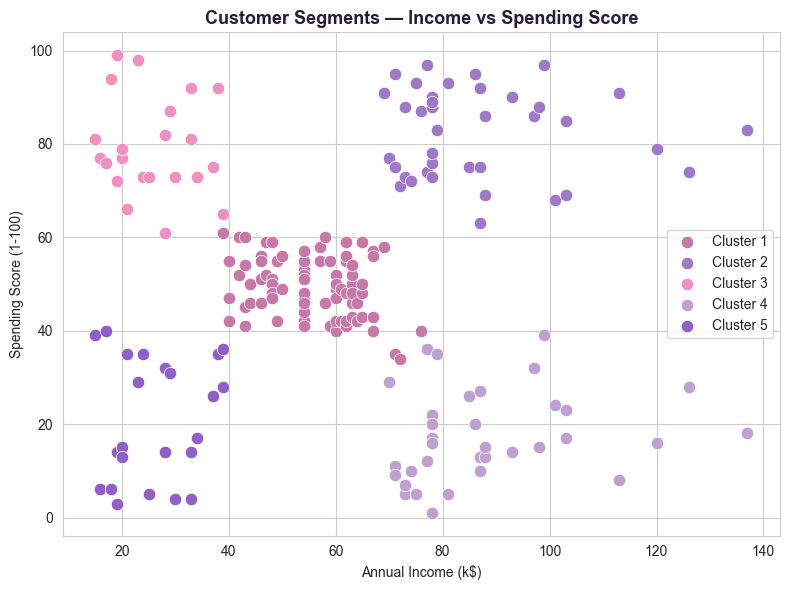

In [37]:
plt.figure(figsize=(8, 6))
for i, color in enumerate(colors):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(
        cluster_data['Annual_Income'],
        cluster_data['Spending_Score'],
        c=color, label=f'Cluster {i+1}',
        s=80, edgecolors='white', linewidth=0.5
    )
plt.title('Customer Segments — Income vs Spending Score',
          fontsize=13, fontweight='bold', color='#2a1a3e')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.tight_layout()
plt.savefig('clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
summary = df.groupby('Cluster').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual_Income', 'mean'),
    Avg_Spending=('Spending_Score', 'mean')
).round(1)
labels = {
    0: ' High Income, Low Spender',
    1: ' High Income, High Spender',
    2: ' Average Everything',
    3: ' Low Income, High Spender',
    4: ' Low Income, Low Spender'
}
summary['Segment Label'] = summary.index.map(labels)
print("\n===== CUSTOMER SEGMENT INSIGHTS =====\n")
print(summary.to_string())


===== CUSTOMER SEGMENT INSIGHTS =====

         Count  Avg_Age  Avg_Income  Avg_Spending               Segment Label
Cluster                                                                      
0           81     42.7        55.3          49.5    High Income, Low Spender
1           39     32.7        86.5          82.1   High Income, High Spender
2           22     25.3        25.7          79.4          Average Everything
3           35     41.1        88.2          17.1    Low Income, High Spender
4           23     45.2        26.3          20.9     Low Income, Low Spender
